# Load Libraries

In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
from keras import Sequential
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.applications import DenseNet121, DenseNet169, DenseNet201, VGG16, VGG19, MobileNetV2, Xception, NASNetMobile, NASNetLarge
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, MaxPooling2D, BatchNormalization, Input, concatenate, GlobalMaxPooling2D, Activation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten
from tensorflow.keras.metrics import Mean, BinaryCrossentropy, Precision, Recall, AUC
from tensorflow.keras.optimizers import Adam,SGD, RMSprop
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from PIL import Image
from sklearn.preprocessing import LabelEncoder
import pickle


from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2, l1_l2, l1
from tensorflow.keras.initializers import he_normal
from tensorflow.keras.metrics import categorical_crossentropy, binary_crossentropy

from sklearn.utils.class_weight import compute_class_weight
from itertools import chain
import sklearn.metrics
import keras


# Define Parameters

In [ ]:
batch_size = 32
target_size = (224, 224)
input_shape = (*target_size, 3)
print('Input shape:',input_shape)

Input shape: (224, 224, 3)


# Dataset Path

In [ ]:
import os
dataset_path = os.path.join(r'F:\train_models\data\white_prawn') #White_prawns_mask_no_aspect
# recent_test = os.path.join(r'F:\Latest_WhitePrawns_DATASETS','TEST','ASPECT')
# MANUAL = os.path.join(r'F:\Latest_WhitePrawns_DATASETS','MANUAL')

In [ ]:
test_path = os.path.join(dataset_path,'test')
train_path = os.path.join(dataset_path,'train')
val_path = os.path.join(dataset_path,'val')
test_path

'F:\\train_models\\data\\white_prawn\\test'

# Pre-processing Function

In [ ]:
def process_image(image):
    resized_image = cv2.resize(image,target_size)
    processed_image = tf.keras.applications.densenet.preprocess_input(resized_image)
    return processed_image


# Image Augmentation

In [ ]:
# train_datagen = ImageDataGenerator(
#     preprocessing_function=process_image,
#     rotation_range=180,              # Randomly rotate images in the range (degrees)
#     width_shift_range=0.05,          # Randomly shift images horizontally (fraction of total width)
#     height_shift_range=0.05,         # Randomly shift images vertically (fraction of total height)
#     shear_range=0.2,                # Shear intensity (shear angle in radians)
#     zoom_range=0.05,                 # Randomly zoom in/out on images
#     horizontal_flip=True,           # Randomly flip images horizontally
#     vertical_flip=True,             # Randomly flip images vertically
#     brightness_range=[0.7, 1.3],    # Randomly adjust brightness
#     channel_shift_range=10,         # Randomly shift color channels
#     fill_mode='constant',           # Fill newly created pixels with a constant value
#     cval=0,                         # Value to fill newly created pixels (black in this case)
# )

train_datagen = ImageDataGenerator(
    preprocessing_function=process_image,  # Your custom preprocessing function
    rotation_range=30,  # Reduce rotation range for phone images (less drastic)
    width_shift_range=0.1,  # Increase width/height shift range for mobile variations
    height_shift_range=0.1,
    shear_range=0.05,  # Further reduce shear for more natural appearance
    zoom_range=0.1,  # Increase zoom range to cover phone zooming
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.4],  # Wider brightness range for diverse lighting
    channel_shift_range=20,  # Increase channel shift for color variations
    fill_mode='constant',
    cval=0
)

test_datagen = ImageDataGenerator(
    preprocessing_function=process_image,
)


# Data Generators

In [ ]:
train = train_datagen.flow_from_directory(
    directory = train_path,
    target_size=target_size,
    batch_size=batch_size,
    shuffle=True,
    class_mode='binary',
)

class_weights = compute_class_weight(
    'balanced', classes=np.unique(train.classes), y=train.classes
)
class_weights_dict = dict(zip(np.unique(train.classes), class_weights))

# Print the computed class weights
print("Class Weights:", class_weights_dict)

val = test_datagen.flow_from_directory(
    directory = val_path,
    target_size=target_size,
    batch_size=batch_size,
    shuffle=False,
    class_mode='binary',
)
test = test_datagen.flow_from_directory(
    directory = test_path,
    target_size=target_size,
    batch_size=batch_size,
    shuffle=False,
    class_mode='binary',
)

Found 25259 images belonging to 2 classes.
Class Weights: {0: 0.973146863923563, 1: 1.0283771679830633}
Found 3086 images belonging to 2 classes.
Found 3102 images belonging to 2 classes.


# Call backs

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define the callback
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-7,
    verbose=1,
    mode = 'min'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

import sklearn

def f1_from_roc(fpr, tpr, pos, neg):
    """Calculate f1 score from roc values.

    Parameters
    ----------
        fpr : float
            The false positive rate.
        tpr : float
            The true positive rate.
        pos : int
            The number of positive labels.
        neg : int
            The number of negative labels.

    Returns
    -------
    float
        The f1 score.
    """
    fp = fpr * neg
    fn = (1 - tpr) * pos
    tp = pos - fn
    f1 = tp / (tp + ((fn + fp) / 2))
    return f1

def pos_neg(labels, pos_label):
    pos = sum(label == pos_label for label in labels)
    neg = sum(label != pos_label for label in labels)
    return pos, neg

def best_f1_score(labels, predictions, pos_label):
    """Calculate best f1 score with its threshold."""
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, predictions, pos_label=pos_label)
    pos, neg = pos_neg(labels, 1)

    best_f1 = -1
    best_f1_threshold = -1

    for fpr_value, tpr_value, t in zip(fpr, tpr, thresholds):
        f1 = f1_from_roc(fpr_value, tpr_value, pos, neg)
        if f1 > best_f1:
            best_f1 = f1
            best_f1_threshold = t
    return best_f1, best_f1_threshold


import sklearn.metrics
import numpy as np
import keras
import tensorflow as tf
from keras.models import save_model


class BinaryClassifierMetricsCallback(keras.callbacks.Callback):
    def __init__(self, val_data, val_labels, pos_label=1, save_path_roc=None, save_path_precision=None, save_path_f1=None):
        super().__init__()
        self.val_data = val_data
        self.val_labels = val_labels
        self.pos_label = pos_label
        self.save_path_roc = save_path_roc
        self.save_path_precision = save_path_precision
        self.save_path_f1 = save_path_f1
        self.best_roc_auc = float('-inf')  # Initialize with negative infinity
        self.best_precision = float('-inf')
        self.best_f1 = float('-inf')
        self.best_f1_threshold_roc = None
        self.best_f1_threshold_precision = None
        self.best_f1_threshold_f1 = None

    def on_epoch_end(self, epoch, logs={}):
        logs = logs or {}
        predict_results = self.model.predict(self.val_data)

        round_predict_results = np.rint(predict_results)

        roc_auc = sklearn.metrics.roc_auc_score(self.val_labels, predict_results)
        logs["roc_auc"] = roc_auc

        average_precision = sklearn.metrics.average_precision_score(self.val_labels, predict_results,
                                                                    pos_label=self.pos_label)
        logs['average_precision'] = average_precision

        f1, f1_threshold = best_f1_score(self.val_labels, predict_results, self.pos_label)
        logs["f1"] = f1
        logs["best_f1_threshold"] = f1_threshold

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.best_f1_threshold_f1 = f1_threshold  # Update best F1 threshold for F1 score
            if self.save_path_f1:
                save_model(self.model, f"{self.save_path_f1}.h5")
                print(f"Epoch {epoch + 1}: Model saved with best F1 score: {f1}")


    def get_best_thresholds(self):
        return {
            "roc_auc": self.best_f1_threshold_roc,
            "average_precision": self.best_f1_threshold_precision,
            "f1": self.best_f1_threshold_f1
        }

    def set_gpu_mem_growth():

        config = tf.ConfigProto()
        config.gpu_options.allow_growth = True
        keras.backend.tensorflow_backend.set_session(tf.Session(config=config))

In [ ]:
callback = BinaryClassifierMetricsCallback(val, val.classes, pos_label=1,
                                          save_path_roc=None,
                                          save_path_precision=None,
                                          save_path_f1='best_model_f1')

# Load existing model (Current model)

In [ ]:
# #### FINE TUNE EXISTING MODEL
model = tf.keras.models.load_model(r'prawn_sept.h5')
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy']) #, clipvalue=1.0
train_steps_per_epoch = len(train)
val_steps_per_epoch = len(val)

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               131200    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 128)               0

# Train model

In [ ]:
with tf.device('/GPU:0'):
    history = model.fit(
        train,
        validation_data=val,
        validation_steps=val_steps_per_epoch,
        epochs=2000,
        callbacks=[callback, early_stopping],
        class_weight=class_weights_dict
    )

Epoch 1/2000
97/97 [==============================] - 17s 156ms/step
Epoch 1: Model saved with best F1 score: 0.9065507606333437
790/790 [==============================] - 1289s 2s/step - loss: 0.3031 - accuracy: 0.8863 - val_loss: 0.2777 - val_accuracy: 0.8973 - roc_auc: 0.9659 - average_precision: 0.9658 - f1: 0.9066 - best_f1_threshold: 0.5197
Epoch 2/2000
97/97 [==============================] - 15s 150ms/step
Epoch 2: Model saved with best F1 score: 0.906905055487053
790/790 [==============================] - 388s 490ms/step - loss: 0.2789 - accuracy: 0.8977 - val_loss: 0.3199 - val_accuracy: 0.8995 - roc_auc: 0.9672 - average_precision: 0.9678 - f1: 0.9069 - best_f1_threshold: 0.4665
Epoch 3/2000
97/97 [==============================] - 14s 149ms/step
Epoch 3: Model saved with best F1 score: 0.9109611057537769
790/790 [==============================] - 377s 477ms/step - loss: 0.2814 - accuracy: 0.8939 - val_loss: 0.3051 - val_accuracy: 0.8840 - roc_auc: 0.9680 - average_precision

# Training Plots for model fine tuning

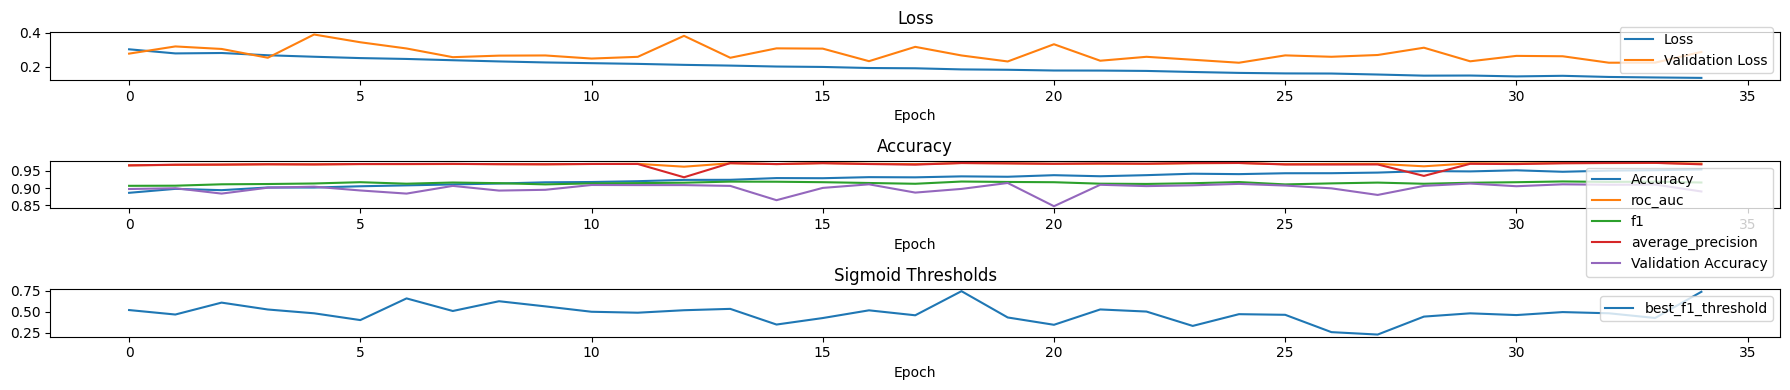

In [ ]:
best_thresholds = callback.get_best_thresholds()

# Plot ROC AUC, average precision, F1 score, loss, and accuracy
plt.figure(figsize=(18, 4))

# ROC AUC
plt.subplot(3, 1, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()


# Accuracy
plt.subplot(3, 1, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['roc_auc'], label='roc_auc')
plt.plot(history.history['f1'], label='f1')
plt.plot(history.history['average_precision'], label='average_precision')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Thresholds
plt.subplot(3, 1, 3)
plt.plot(history.history['best_f1_threshold'], label='best_f1_threshold')
plt.title('Sigmoid Thresholds')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Model evaluation with Confusion Matrix and Classification reports

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def evaluate_binary_classification_model(model, test_generator, threshold=0.5):
    y_true = test_generator.classes
    y_pred_prob = model.predict(test_generator, verbose=1)
    y_pred_labels = (y_pred_prob > threshold).astype(int)

    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_labels, target_names=test_generator.class_indices.keys()))

    # Plot confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred_labels)
    plot_confusion_matrix(cnf_matrix, classes=test_generator.class_indices.keys())

97/97 [==============================] - 15s 159ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.92      0.90      0.91      1519
        good       0.91      0.92      0.91      1567

    accuracy                           0.91      3086
   macro avg       0.91      0.91      0.91      3086
weighted avg       0.91      0.91      0.91      3086

Confusion matrix, without normalization


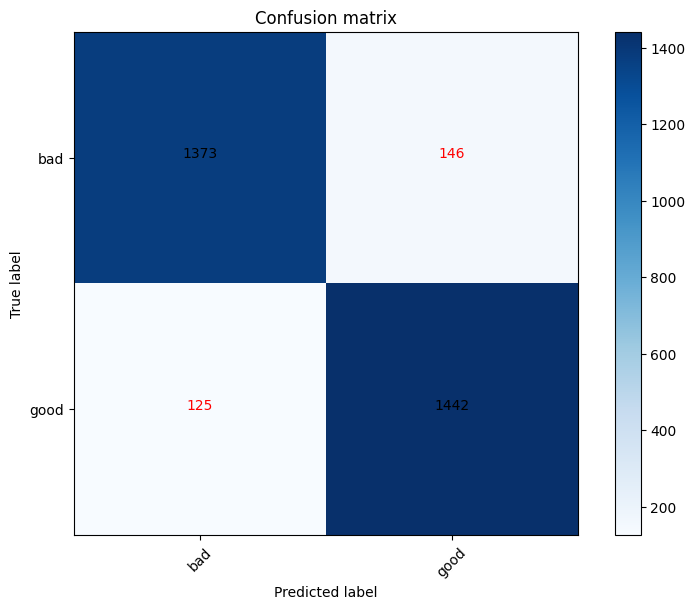

In [ ]:
evaluate_binary_classification_model(model,val,0.5)

97/97 [==============================] - 52s 539ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.91      0.91      0.91      1527
        good       0.92      0.91      0.91      1575

    accuracy                           0.91      3102
   macro avg       0.91      0.91      0.91      3102
weighted avg       0.91      0.91      0.91      3102

Confusion matrix, without normalization


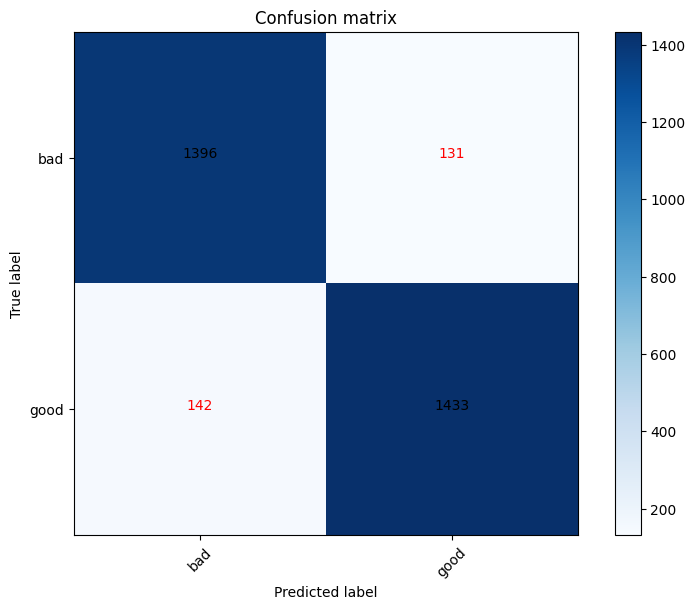

In [ ]:
evaluate_binary_classification_model(model,test,0.5 )

In [ ]:
model.save('Prawn(sigmoid).h5')

# F1 Score

In [ ]:
model_f1 = tf.keras.models.load_model("best_model_f1.h5")


Evaluation for Model with Best F1 Score: 0.4955823
97/97 [==============================] - 18s 160ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.94      0.89      0.91      1519
        good       0.90      0.94      0.92      1567

    accuracy                           0.92      3086
   macro avg       0.92      0.92      0.92      3086
weighted avg       0.92      0.92      0.92      3086

Confusion matrix, without normalization


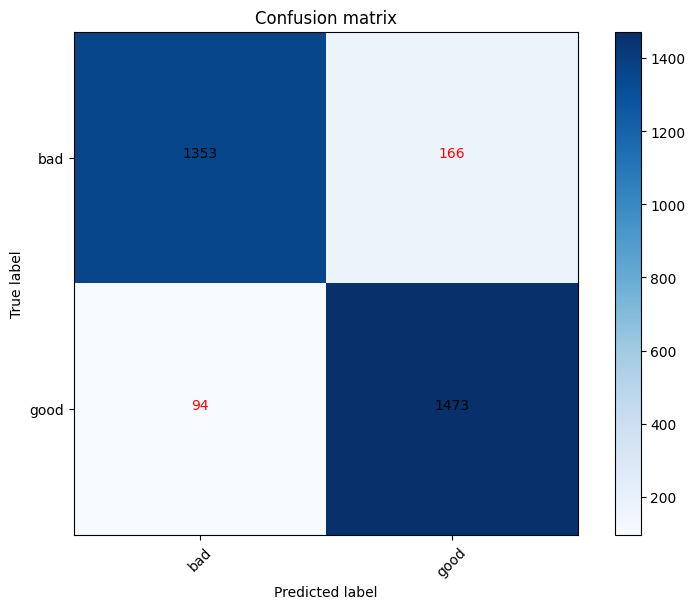

97/97 [==============================] - 15s 151ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.93      0.90      0.91      1527
        good       0.90      0.94      0.92      1575

    accuracy                           0.92      3102
   macro avg       0.92      0.92      0.92      3102
weighted avg       0.92      0.92      0.92      3102

Confusion matrix, without normalization


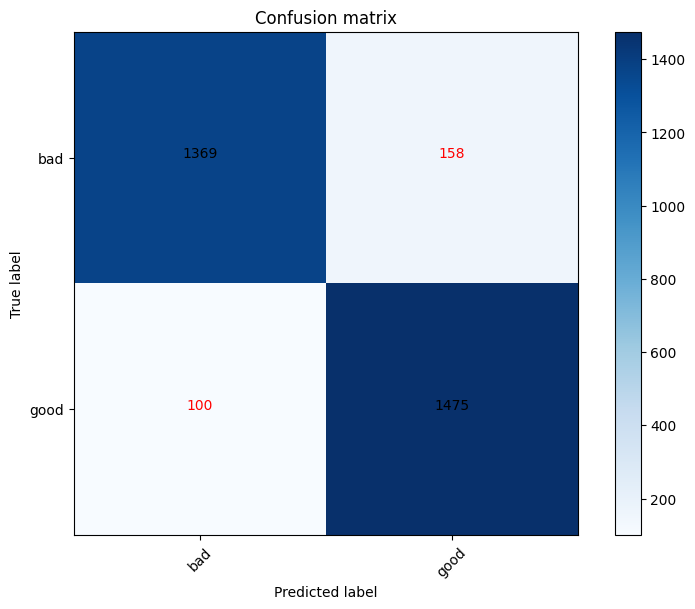

In [ ]:
print("\nEvaluation for Model with Best F1 Score:",best_thresholds["f1"])
evaluate_binary_classification_model(model_f1, val, threshold=best_thresholds["f1"])
evaluate_binary_classification_model(model_f1, test, threshold=best_thresholds["f1"])